In [1]:
from glob import glob
import cv2
import matplotlib.pyplot as plt
from subspaceadonnx import SubspaceAD

In [2]:
# Prepare directories with good images and images with defects
NORMAL_IMG_DIR = "datasets/transistor/train/good"
TARGET_IMG_DIR = "datasets/transistor/test/bent_lead"

In [3]:
model = SubspaceAD(
    "models/dinov3_vitb_448_dual.onnx", # prepared model using export_onnx.py
    providers=["WebGpuExecutionProvider"]
)

### Fit model

In [4]:
# normal_imgs = [cv2.imread(f) for f in glob(f"{NORMAL_IMG_DIR}/*.png")]
model.fit(NORMAL_IMG_DIR)  # pass directory containing images or list[np.ndarray]

Extracting features:   0%|          | 0/213 [00:00<?, ?images/s]

Fitting PCA on 150528 patch tokens with feature dim 768.
Calibrating anomaly-map scale
Anomaly-map scale calibrated: offset=0.378087, fit_max=2.34246, scale=0.254534, scaled_max=0.5, pixel_threshold=0.248946, image_threshold=0.431074


In [5]:
def visualize_anomaly_map(target_img, 
                          anomaly_map, 
                          image_score,
                          threshold=0.5,
                          vmin=0.0,
                          vmax=1.0,
                          color_map="viridis"):
    """
    target_img: BGR HWC
    anomaly_map: HW float32
    image_score: float
    threshold: float, anomaly_mapの閾値
    """
    plt.figure(figsize=(12, 4))
    fig, axs = plt.subplots(1, 4, figsize=(12, 4))
    axs[0].imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
    axs[0].set_title("Input Image")
    axs[1].imshow(anomaly_map, cmap=color_map, vmin=vmin, vmax=vmax)
    axs[1].set_title(f"Anomaly Map (score={image_score:.2f})")
    axs[2].imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
    axs[2].imshow(anomaly_map, cmap=color_map, alpha=0.5, vmin=vmin, vmax=vmax)
    axs[2].set_title("Overlay")
    axs[3].imshow(anomaly_map > threshold, cmap="gray")
    axs[3].set_title(f"Thresholded (>{threshold})")
    for ax in axs:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


<Figure size 1200x400 with 0 Axes>

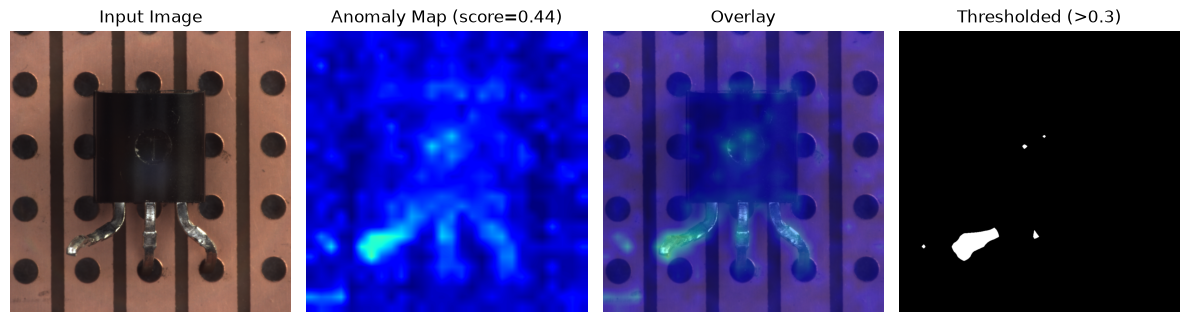

<Figure size 1200x400 with 0 Axes>

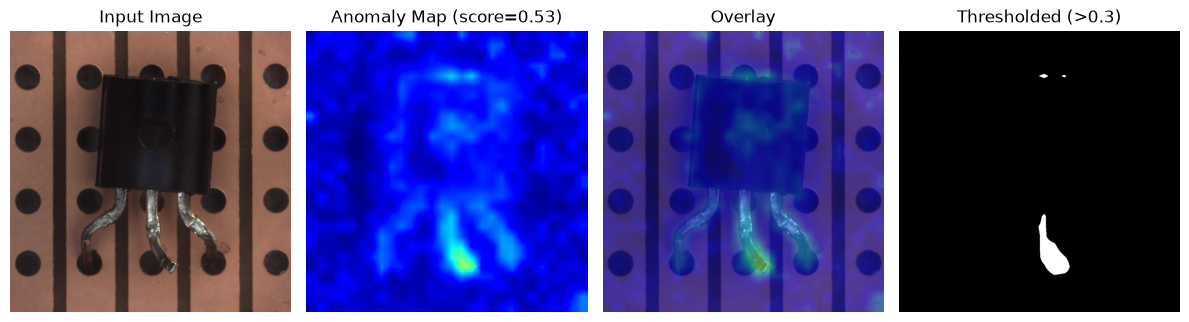

<Figure size 1200x400 with 0 Axes>

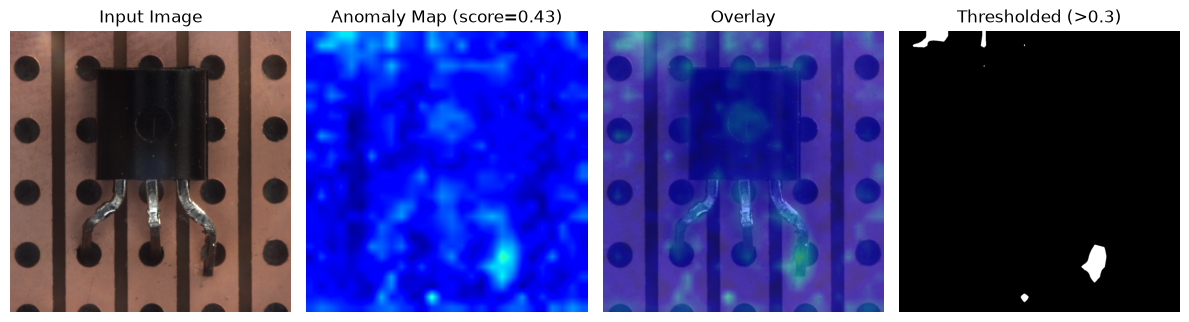

<Figure size 1200x400 with 0 Axes>

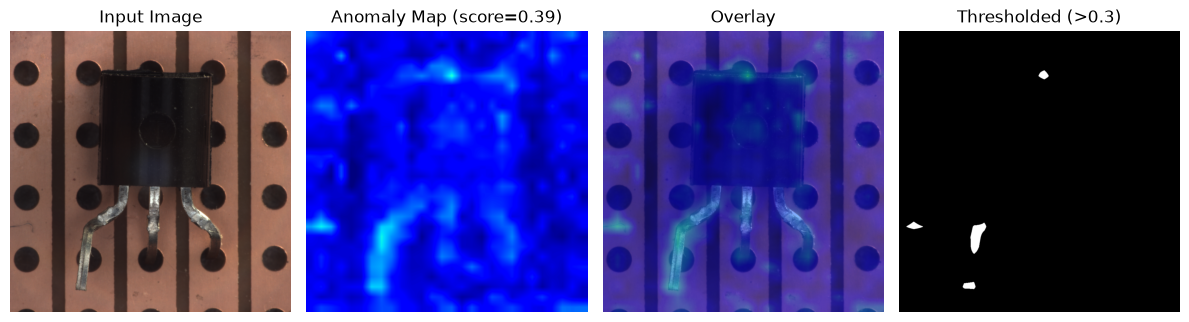

<Figure size 1200x400 with 0 Axes>

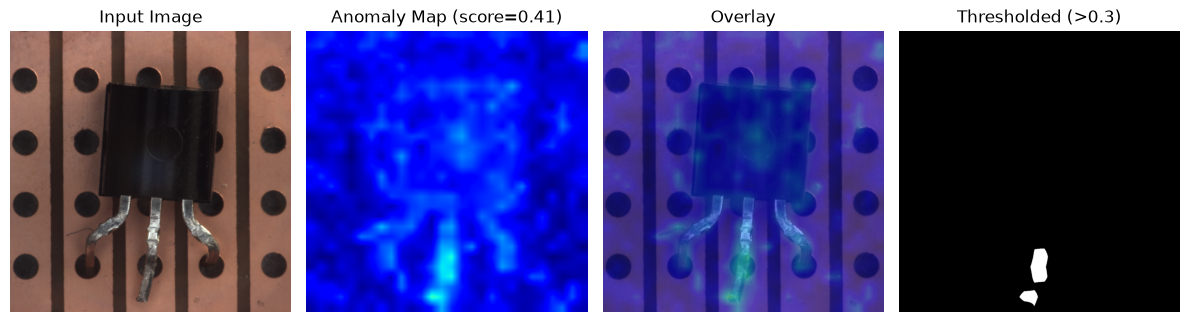

<Figure size 1200x400 with 0 Axes>

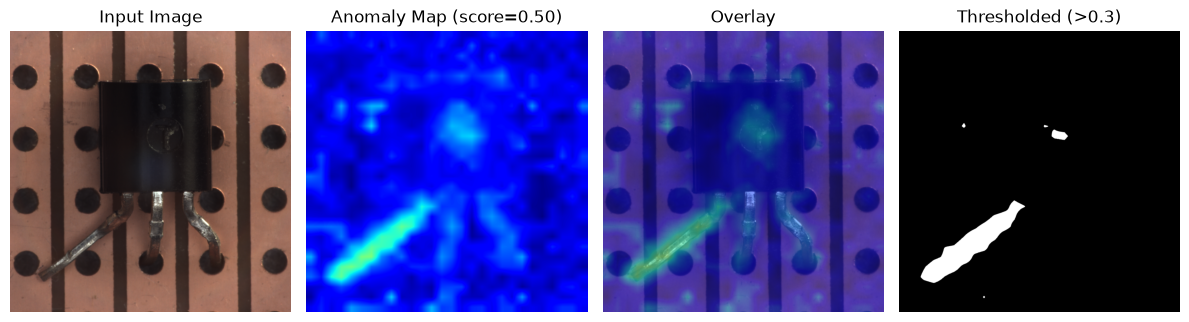

<Figure size 1200x400 with 0 Axes>

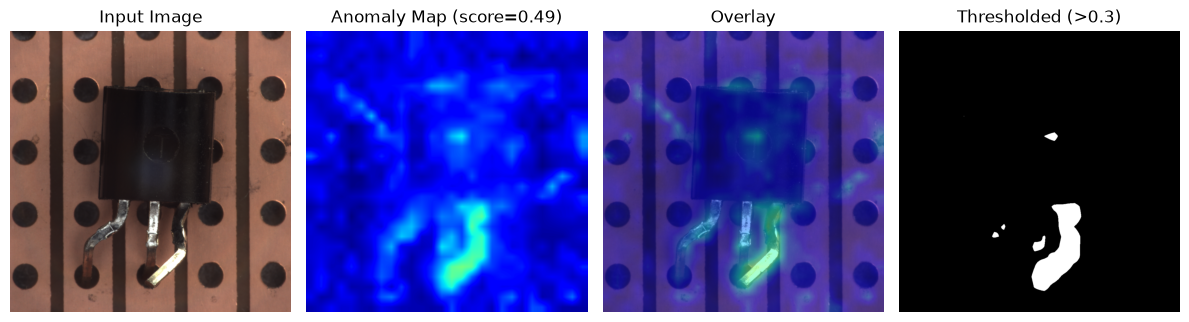

<Figure size 1200x400 with 0 Axes>

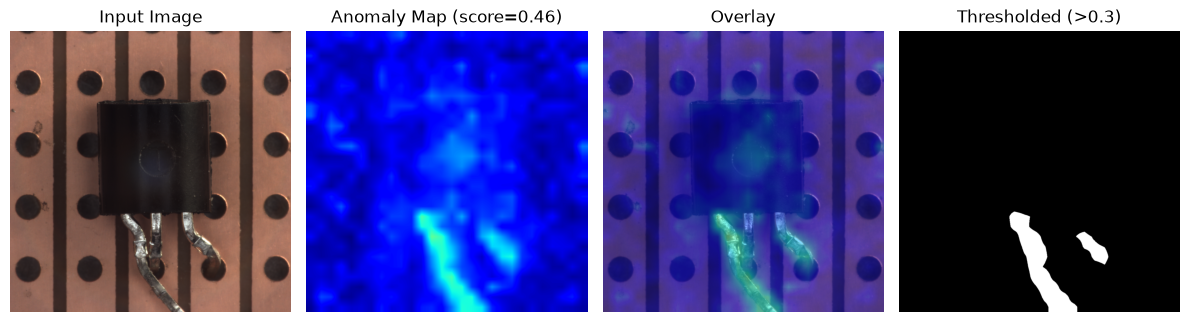

<Figure size 1200x400 with 0 Axes>

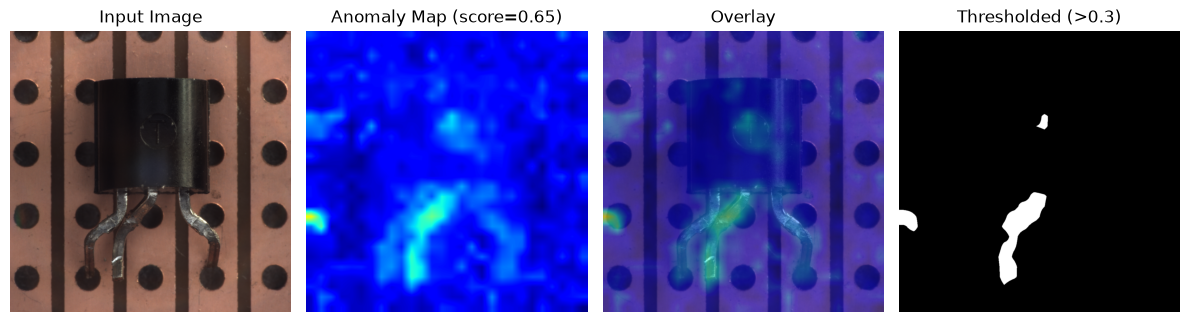

<Figure size 1200x400 with 0 Axes>

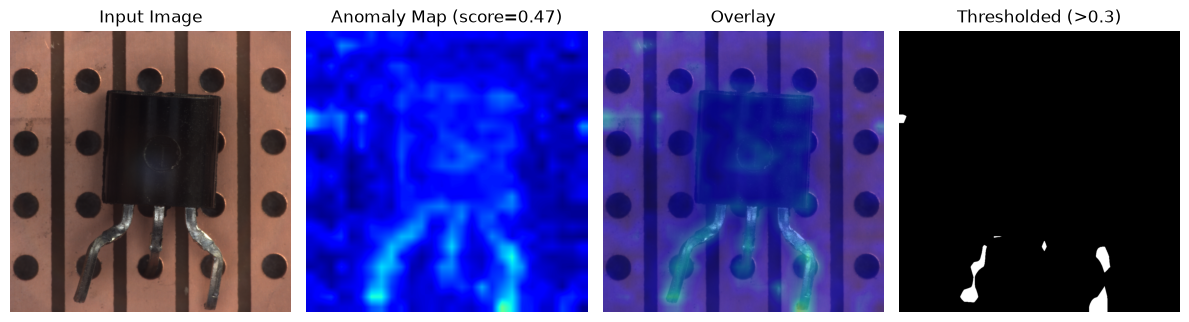

In [8]:
target_imgs = [cv2.imread(f) for f in glob(f"{TARGET_IMG_DIR}/*.png")]
for target_img in target_imgs[:10]:
    anomaly_map = model(target_img)
    image_score = model.image_score(target_img, method="max")
    visualize_anomaly_map(target_img, anomaly_map, image_score, 
                          threshold=0.3,vmin=0.0,vmax=1, color_map="jet")

### Save & load fitted model

In [ ]:
# save PCA parameters to a file
pca_params = model.save_npz("models/pca_params.npz")
# load PCA parameters from a file
#model.load_npz("models/pca_params.npz")

### Run evaluation on MVTec Dataset

In [117]:
from subspaceadonnx import MVTecEvaluator

evaluator = MVTecEvaluator(
    dataset_root="datasets",
    dataset_names=["bottle", "capsule","carpet","grid",
                   "hazelnut", "leather","screw","tile",
                   "toothbrush", "transistor", "wood"],
    onnx_path="models/dinov3_vitsplus_224_dual.onnx",
    providers=["WebGpuExecutionProvider"]
)
result = evaluator.evaluate(save_hist=True)
for key, v in result.items():
    print(f"{key}: {v}")

[MVTec 1/11][bottle] Start fitting (209imgs)


Extracting features:   0%|          | 0/209 [00:00<?, ?images/s]

Fitting PCA on 36848 patch tokens with feature dim 384.


Calibrating anomaly-map scale:   0%|          | 0/209 [00:00<?, ?images/s]

Anomaly-map scale calibrated: offset=0.114707, fit_max=3.0381, scale=0.171034, scaled_max=0.5, pixel_threshold=0.297075, image_threshold=0.427631
[MVTec 1/11][bottle] Training completed


...

Fitting PCA on 43512 patch tokens with feature dim 384.


Calibrating anomaly-map scale:   0%|          | 0/247 [00:00<?, ?images/s]

Anomaly-map scale calibrated: offset=0.400103, fit_max=2.14008, scale=0.28736, scaled_max=0.5, pixel_threshold=0.290549, image_threshold=0.499213
[MVTec 11/11][wood] Training completed


[MVTec 11/11][wood] Inference:   0%|          | 0/79 [00:00<?, ?images/s]

[MVTec 11/11][wood] Start evaluation
[MVTec 11/11][wood] Evaluation completed (image AUROC=0.9798, pixel AUROC=0.9585)
date: 2026-07-05 11:00:33
description: dinov3_vitsplus_224_dual
datasets: bottle;capsule;carpet;grid;hazelnut;leather;screw;tile;toothbrush;transistor;wood
img_auroc: 0.9587456621874458
img_aupr: 0.9790799264382604
seg_auroc: 0.9801528351038539
seg_pro: 0.9249263780685588
